In [1]:
# Import the main libraries for data analysis

import pandas as pd
import numpy as np

In [2]:
# Load the dataset from a CSV file into a DataFrame

df = pd.read_csv('retail_store_sales.csv')
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [3]:
# Check the dataset structure: column names, data types, and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [4]:
# Check the number of rows and columns in the dataset

df.shape

(12575, 11)

In [5]:
# Preview the first 5 rows to understand the data format

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [6]:
# Check how many missing values exist in each column

df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [7]:
# Clean column names: remove spaces, make lowercase, and use underscores
# This makes column names easier to use in code

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"\s+", "_", regex=True)
)

In [8]:
# Check the unique values in the transaction_date column (before converting)

df["transaction_date"].unique()

array(['2024-04-08', '2023-07-23', '2022-10-05', ..., '2023-03-17',
       '2024-02-29', '2022-09-16'], shape=(1114,), dtype=object)

In [9]:
# Convert transaction_date from text to datetime format
# errors="coerce" will turn invalid dates into NaN

df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

In [10]:
# Convert the discount_applied column to a clean boolean format (True/False)
# We first convert to string, clean the text, and then map values to boolean

df["discount_applied"] = (df["discount_applied"].astype("string").str.strip().str.lower().map({"true": True, "false": False}))

In [11]:
# Check the unique values after cleaning (to confirm conversion worked)

df["discount_applied"].unique()

array([True, False, nan], dtype=object)

In [12]:
# Convert numeric columns to proper numeric type
# errors="coerce" changes invalid values into NaN

num_cols = ["price_per_unit", "quantity", "total_spent"] 
for c in num_cols: 
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [13]:
# Check for duplicate transaction IDs (transaction_id should be unique)

duplicate_for_id = df.duplicated(subset=["transaction_id"]).sum()
print("Duplicate Transaction ID:", duplicate_for_id)

Duplicate Transaction ID: 0


In [14]:
# Check for invalid numeric values (negative or zero values)
# This helps detect data entry errors

for c in ["price_per_unit", "quantity", "total_spent"]:
    print(c, "min =", df[c].min(), "zero_count =", (df[c] == 0).sum(), "neg_count =", (df[c] < 0).sum())


price_per_unit min = 5.0 zero_count = 0 neg_count = 0
quantity min = 1.0 zero_count = 0 neg_count = 0
total_spent min = 5.0 zero_count = 0 neg_count = 0


In [15]:
# Create a calculated total (price_per_unit * quantity) to validate total_spent

df["calc_total"] = df["price_per_unit"] * df["quantity"]

# If the difference is near zero, the totals are consistent

df["total_diff"] = df["total_spent"] - df["calc_total"]

In [16]:
# Set a small tolerance for rounding differences (e.g., cents)

tolerance = 0.01

# Find rows where total_spent does not match price_per_unit * quantity (beyond tolerance)

inconsistent = df.loc[
    df["total_spent"].notna() & df["calc_total"].notna() & (df["total_diff"].abs() > tolerance)
]

# Print how many inconsistent rows exist

print("Inconsistent totals:", len(inconsistent))

Inconsistent totals: 0


In [17]:
# Show the percentage of missing values in each column (from highest to lowest)

missing = df.isna().mean().sort_values(ascending=False) 
print(missing)

discount_applied    0.333917
item                0.096461
calc_total          0.096461
total_diff          0.096461
price_per_unit      0.048429
quantity            0.048032
total_spent         0.048032
transaction_id      0.000000
customer_id         0.000000
category            0.000000
payment_method      0.000000
location            0.000000
transaction_date    0.000000
dtype: float64


In [18]:
# Check how many of the key numeric columns are missing per row


cols = ["price_per_unit", "quantity", "total_spent"]
df["missing_count_pqt"] = df[cols].isna().sum(axis=1)

# Count how many rows have 0, 1, 2, or 3 missing values in these columns

df["missing_count_pqt"].value_counts().sort_index()

missing_count_pqt
0    11362
1      609
2      604
Name: count, dtype: int64

In [19]:
# Fill missing values using the business rule:
# total_spent = price_per_unit * quantity
# If two values exist, we can calculate the third one.

# 1) If total_spent is missing, calculate it using price_per_unit and quantity

df.loc[df["total_spent"].isna(), "total_spent"] = df["price_per_unit"] * df["quantity"]

# 2) If price_per_unit is missing, calculate it using total_spent and quantity

df.loc[df["price_per_unit"].isna(), "price_per_unit"] = df["total_spent"] / df["quantity"]

# 3) If quantity is missing, calculate it using total_spent and price_per_unit

df.loc[df["quantity"].isna(), "quantity"] = df["total_spent"] / df["price_per_unit"]

In [20]:
# Check how many missing values are left in the main numeric columns

df[["price_per_unit","quantity","total_spent"]].isna().sum()

price_per_unit      0
quantity          604
total_spent       604
dtype: int64

In [21]:
# Remove rows where total_spent is missing (these rows cannot be used for sales analysis)
# .copy() is used to avoid SettingWithCopyWarning in later steps

df = df[df["total_spent"].notna()].copy()

In [22]:
# Confirm that quantity and total_spent have no missing values after filtering

df[["quantity", "total_spent"]].isna().sum()

quantity       0
total_spent    0
dtype: int64

In [23]:
# Check missing values again for the full dataset

df.isna().sum()

transaction_id          0
customer_id             0
category                0
item                  609
price_per_unit          0
quantity                0
total_spent             0
payment_method          0
location                0
transaction_date        0
discount_applied     3988
calc_total            609
total_diff            609
missing_count_pqt       0
dtype: int64

In [24]:
# Fill missing item values with a placeholder label
# This allows us to keep the rows for category-level analysis

df["item"] = df["item"].fillna("Unknown")

In [25]:
# Fill missing discount_applied values with a placeholder label
# We use "Unknown" because missing does not always mean False

df["discount_applied"] = df["discount_applied"].fillna("Unknown")

In [26]:
# Drop temporary columns that were created only for checking data consistency

df = df.drop(columns=["calc_total", "total_diff", "missing_count_pqt"], errors="ignore")

In [27]:
# Convert discount_applied to string so it is consistent (e.g., True/False/Unknown)

df["discount_applied"] = df["discount_applied"].astype(str)

In [28]:
# Final check: confirm there are no missing values remaining

df.isna().sum()

transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
discount_applied    0
dtype: int64

In [29]:
# Calculate total sales (total revenue) across all transactions

df["total_spent"].sum()

np.float64(1552071.0)

In [30]:
# Calculate the average spend per transaction (average order value)

df["total_spent"].mean()

np.float64(129.6525770612313)

In [31]:
# Outlier detection using the IQR (Tukey fences) method
# We calculate Q1, Q3, IQR, and then define lower/upper limits.
# Values outside these limits are considered potential outliers.

def iqr_outlier_summary(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_rows = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\nColumn: {col}")
    print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
    print(f"Lower limit: {lower}, Upper limit: {upper}")
    print("Outlier row count:", len(outlier_rows))
    
    return lower, upper, outlier_rows

# Run the outlier check for the key numeric columns
low_ts, up_ts, out_ts = iqr_outlier_summary(df, "total_spent")
low_ppu, up_ppu, out_ppu = iqr_outlier_summary(df, "price_per_unit")
low_qty, up_qty, out_qty = iqr_outlier_summary(df, "quantity")

# Show the top outlier transactions for total_spent
out_ts[["transaction_id", "category", "price_per_unit", "quantity", "total_spent"]].sort_values(
    "total_spent", ascending=False
).head(10)


Column: total_spent
Q1: 51.0, Q3: 192.0, IQR: 141.0
Lower limit: -160.5, Upper limit: 403.5
Outlier row count: 60

Column: price_per_unit
Q1: 14.0, Q3: 33.5, IQR: 19.5
Lower limit: -15.25, Upper limit: 62.75
Outlier row count: 0

Column: quantity
Q1: 3.0, Q3: 8.0, IQR: 5.0
Lower limit: -4.5, Upper limit: 15.5
Outlier row count: 0


,transaction_id,category,price_per_unit,quantity,total_spent
27,TXN_1599706,Furniture,41.0,10.0,410.0
133,TXN_2953434,Furniture,41.0,10.0,410.0
7520,TXN_9553259,Food,41.0,10.0,410.0
7716,TXN_9628331,Food,41.0,10.0,410.0
7769,TXN_8688342,Furniture,41.0,10.0,410.0
8076,TXN_3858239,Food,41.0,10.0,410.0
8508,TXN_4771109,Electric household essentials,41.0,10.0,410.0
8596,TXN_2288041,Food,41.0,10.0,410.0
8611,TXN_3342443,Butchers,41.0,10.0,410.0
8845,TXN_4208189,Butchers,41.0,10.0,410.0


In [32]:
# Calculate total sales for each category and show the top categories by revenue
# Based on total_spent, the highest sales come from Butchers, Electric household essentials, and Beverages.

df.groupby("category")["total_spent"].sum().sort_values(ascending=False).head(10)

category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: total_spent, dtype: float64

In [33]:
# Compare sales performance by location (Online vs In-store).
# Online sales are slightly higher than in-store sales in total revenue.

df.groupby("location")["total_spent"].agg(["sum","mean","count"])

,sum,mean,count
location,,,
In-store,760670.0,128.861596,5903
Online,791401.0,130.422050,6068


In [34]:
# Summarise total_spent by payment method.
# Cash generates the highest total revenue and the highest number of transactions.

df.groupby("payment_method")["total_spent"].agg(["sum","mean","count"]).sort_values("sum", ascending=False)

,sum,mean,count
payment_method,,,
Cash,537710.0,131.052888,4103
Digital Wallet,507279.0,128.718346,3941
Credit Card,507082.0,129.127069,3927


In [35]:
# Calculate total monthly sales by grouping the data by month (Year-Month)

df.groupby(df["transaction_date"].dt.to_period("M"))["total_spent"].sum()

transaction_date
2022-01    52911.5
2022-02    43325.5
2022-03    40996.0
2022-04    40442.0
2022-05    40347.5
2022-06    42576.0
2022-07    44471.5
2022-08    41333.5
2022-09    46113.5
2022-10    38355.0
2022-11    41256.5
2022-12    38201.0
2023-01    48052.5
2023-02    39214.5
2023-03    38534.5
2023-04    38905.5
2023-05    40480.5
2023-06    42474.0
2023-07    45632.5
2023-08    38592.0
2023-09    41069.0
2023-10    38322.0
2023-11    37014.0
2023-12    43021.0
2024-01    47908.5
2024-02    37145.0
2024-03    42861.5
2024-04    46271.0
2024-05    43766.5
2024-06    44721.0
2024-07    41405.0
2024-08    43362.0
2024-09    42161.5
2024-10    42736.5
2024-11    44076.0
2024-12    48466.5
2025-01    25548.5
Freq: M, Name: total_spent, dtype: float64

In [36]:
# Analyse whether transactions with discounts have different spending patterns.
# We compare mean/median spend, number of transactions, and total revenue.

df.groupby("discount_applied")["total_spent"].agg(["mean","median","count","sum"])

,mean,median,count,sum
discount_applied,,,,
False,129.953330,109.5,3964,515135.0
True,130.491043,109.5,4019,524443.5
Unknown,128.508651,105.0,3988,512492.5


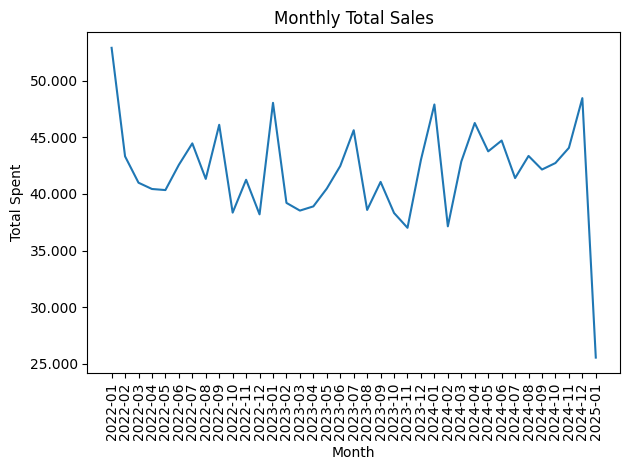

In [37]:
# Plot monthly total sales over time.

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

monthly_sales = df.groupby(df["transaction_date"].dt.to_period("M"))["total_spent"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.xticks(rotation=90)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

plt.tight_layout()
plt.show()

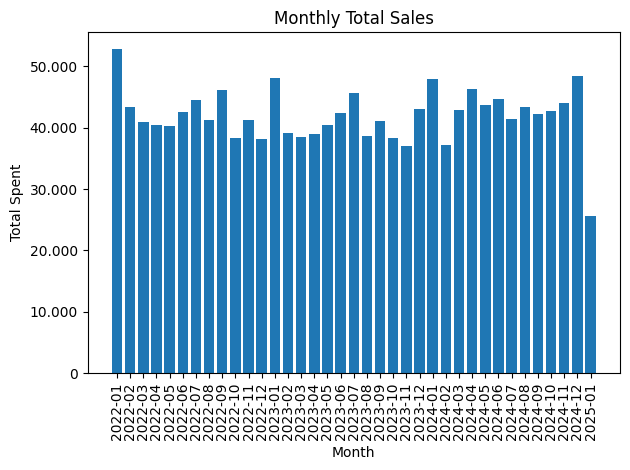

In [38]:
# Plot monthly total sales as a bar chart.

plt.figure()
plt.bar(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.xticks(rotation=90)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", "."))
)

plt.tight_layout()
plt.show()

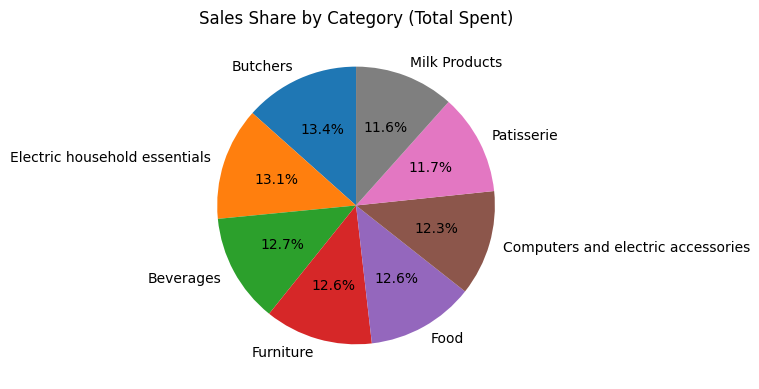

In [39]:
# Create a pie chart to show the share of total sales by category.

cat_sales = df.groupby("category")["total_spent"].sum().sort_values(ascending=False)

plt.figure()
plt.pie(cat_sales.values, labels=cat_sales.index, autopct="%1.1f%%", startangle=90)
plt.title("Sales Share by Category (Total Spent)")
plt.tight_layout()
plt.show()

In [40]:
# Total spending by customer
cust_spend = df.groupby("customer_id")["total_spent"].sum().sort_values(ascending=False)

# Top 1 customer
top_customer = cust_spend.index[0]
top_amount = cust_spend.iloc[0]
print("Top customer:", top_customer)
print("Total spent:", top_amount)

# Top 10 customers
cust_spend.head(10)

Top customer: CUST_24
Total spent: 68452.0


customer_id
CUST_24    68452.0
CUST_08    67351.5
CUST_05    66974.5
CUST_16    65570.5
CUST_13    65037.0
CUST_23    64507.0
CUST_10    63155.5
CUST_15    63117.5
CUST_21    62933.0
CUST_02    62046.5
Name: total_spent, dtype: float64

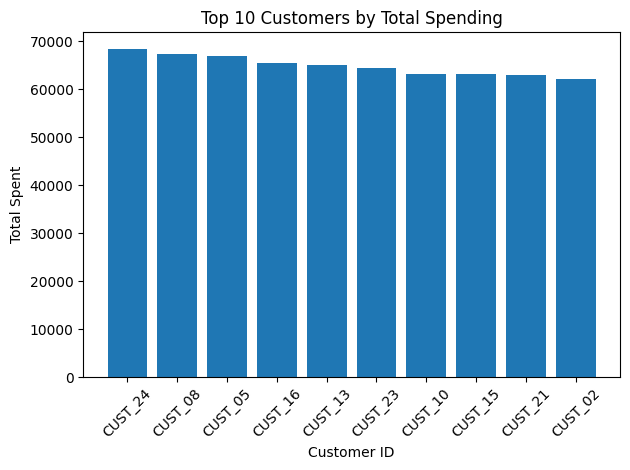

In [41]:
# Visualise the top 10 customers by total spending.

top10 = cust_spend.head(10)

plt.figure()
plt.bar(top10.index, top10.values)
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spent")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

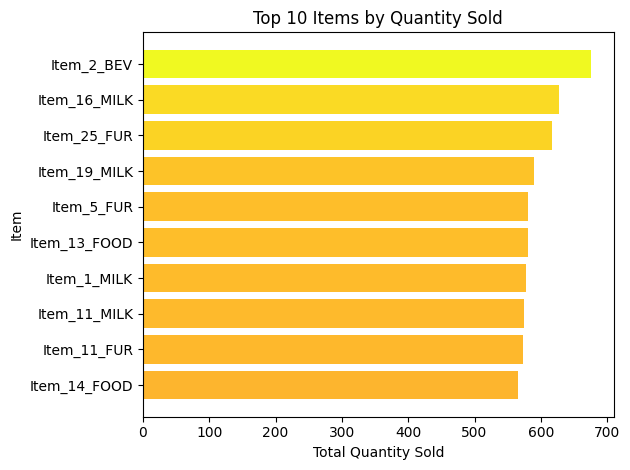

In [42]:
# Visualise the top 10 items by total quantity sold.

item_qty = df[df["item"] != "Unknown"].groupby("item")["quantity"].sum().sort_values(ascending=False)
top_items = item_qty.head(10).sort_values()

colors = plt.cm.plasma(top_items.values / top_items.values.max())

plt.figure()
plt.barh(top_items.index, top_items.values, color=colors)
plt.title("Top 10 Items by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

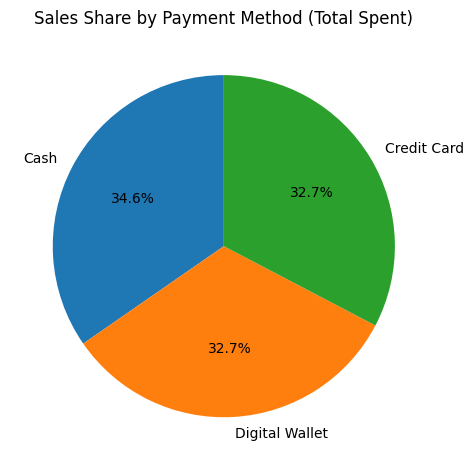

In [43]:
# Create a pie chart to show the share of total sales by payment method.

pay_sum = df.groupby("payment_method")["total_spent"].sum().sort_values(ascending=False)

plt.figure()
plt.pie(
    pay_sum.values,
    labels=pay_sum.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales Share by Payment Method (Total Spent)")
plt.tight_layout()
plt.show()

In [44]:
# Save the cleaned dataset to a new CSV file
df.to_csv("retail_store_sales_cleaned.csv", index=False)

## Key Insights

- Total sales are highest in Butchers, Electric household essentials, and Beverages.

- Online sales are slightly higher than In-store, and average spend per transaction is very similar.

- Cash has the highest revenue and transaction count; other payment methods are close.

- Discount transactions show very similar median spending to non-discount transactions, so the impact is unclear.

- Monthly sales fluctuate; 2025 includes only January, so 2025 trends are not reliable yet.


## Recommendations

- Reduce “Unknown” values to improve product and promotion analysis.

- Prioritise inventory and marketing for the top 3 revenue categories, and investigate why they outperform.

- Test actions to increase online conversion (better product recommendations, smoother checkout).

- Track discount %/amount (not only True/False) and test targeted discounts by category and channel to measure effectiveness.